# Notebook 13 – Regression Evaluation

**Big idea:** a regression model predicts a **number**. Evaluation metrics tell us **how far off those predictions are**.

**Dataset:** data.csv – sales of an online gift shop (Dec 2010 – Dec 2011). Each row is one product line on a customer's bill (invoice).

**Our task:** predict the **total amount of an invoice (£)** from
1. n_items – how many product lines are on the bill
2. total_qty – how many units were bought in total

## Step 1 – Load and prepare the data

In [5]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("data.csv", encoding="ISO-8859-1", dtype={"InvoiceNo": str, "StockCode": str})
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
sales = df[~df.InvoiceNo.str.startswith("C") & (df.Quantity > 0) & (df.UnitPrice > 0)].copy()
sales["Amount"] = sales.Quantity * sales.UnitPrice
inv = sales.groupby("InvoiceNo").agg(n_items=("StockCode", "count"),
                                     total_qty=("Quantity", "sum"),
                                     amount=("Amount", "sum"))
inv = inv[inv.amount < 5000]         
inv.head()

,n_items,total_qty,amount
InvoiceNo,,,
536365,7,40,139.12
536366,2,12,22.20
536367,12,83,278.73
536368,4,15,70.05
536369,1,3,17.85


## Step 2 – Train a simple model and predict

In [7]:
X = inv[["n_items", "total_qty"]]
y = inv["amount"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)
pred = model.predict(X_test)
print("Test invoices:", len(y_test))

Test invoices: 3955


### Our small example: 5 invoices
Below are 5 invoices from the test set: the **actual** amount, what the model **predicted**, and the **error** (`actual − predicted`), rounded to whole pounds. Every metric is just a different way of summarising these errors.

In [8]:
five = pd.DataFrame({"actual": y_test.values[:5].round(), "predicted": pred[:5].round()})
five["error"] = five.actual - five.predicted
five

,actual,predicted,error
0,388.0,792.0,-404.0
1,224.0,276.0,-52.0
2,811.0,520.0,291.0
3,200.0,214.0,-14.0
4,35.0,86.0,-51.0



## 1. MAE – Mean Absolute Error

**What is it?** The *average* size of the mistakes, ignoring whether we guessed too high or too low.

**Example:** errors are −404, −52, 291, −14, −51 → drop the minus signs → 404, 52, 291, 14, 51 → average = 812 ÷ 5 = **£162.4**.

**Why use it?** It is the easiest to explain: *"on average, our predicted bill is off by about £162."* It is not thrown off much by a few very large mistakes.

In [9]:
print("MAE (5 invoices):  ", mean_absolute_error(five.actual, five.predicted))
print("MAE (all test set):", round(mean_absolute_error(y_test, pred), 2))

MAE (5 invoices):   162.4
MAE (all test set): 166.03



## 2. MSE – Mean Squared Error

**What is it?** Square every error, then take the average. Squaring makes **big mistakes count much more** (error 400 → 160,000, but error 14 → 196).

**Example:** 163,216 + 2,704 + 84,681 + 196 + 2,601 = 253,398 → ÷ 5 = **50,679.6**.

**Why use it?** It punishes large errors, and it is what many models minimise while learning. Downside: the unit is *£²*, which is hard to picture.

In [10]:
print("MSE (5 invoices):  ", mean_squared_error(five.actual, five.predicted))
print("MSE (all test set):", round(mean_squared_error(y_test, pred), 2))

MSE (5 invoices):   50679.6
MSE (all test set): 108108.06



## 3. RMSE – Root Mean Squared Error

**What is it?** The square root of MSE, so the answer is back in **pounds**.

**Example:** √50,679.6 ≈ **£225.1**.

**Why use it?** It keeps MSE's "punish big errors" idea but is easy to read. RMSE is always ≥ MAE. **If RMSE is much bigger than MAE, a few big mistakes are hiding in the data** – we will see this on the full test set below.

In [11]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE (all test set):", round(rmse, 2))
print("MAE  (all test set):", round(mean_absolute_error(y_test, pred), 2), " <- RMSE is about double: some invoices are predicted very badly")

RMSE (all test set): 328.8
MAE  (all test set): 166.03  <- RMSE is about double: some invoices are predicted very badly


## 4. R² Score

**What is it?** *How much of the ups and downs in the real values does the model explain?* It compares our model with the laziest model possible: always guessing the average bill.

| R² | Meaning |
|----|---------|
| 1 | perfect |
| 0.6 | explains 60% of the variation |
| 0 | no better than guessing the average |
| below 0 | worse than guessing the average |

**Why use it?** It has no units, so it is easy to judge ("closer to 1 is better") and to compare models on the same data.

In [12]:
r2 = r2_score(y_test, pred)
print("R²:", round(r2, 3), f"-> our model explains about {r2:.0%} of the variation in invoice amounts")

R²: 0.628 -> our model explains about 63% of the variation in invoice amounts



## 5. Adjusted R²

**What is it?** R² has a flaw: it goes **up whenever you add a feature, even a useless one**. Adjusted R² adds a penalty for every extra feature.

`Adjusted R² = 1 − (1 − R²) × (n − 1) / (n − p − 1)`  where `n` = number of rows, `p` = number of features.

**Why use it?** To compare models that use **different numbers of features** more fairly.

In [13]:
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("R²:         ", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2(r2, n=len(y_test), p=2), 4), "  (almost the same: we have thousands of rows and only 2 features)")

R²:          0.628
Adjusted R²: 0.6279   (almost the same: we have thousands of rows and only 2 features)


### Demo: what happens when we add useless columns?
We train on only **30 invoices**, then add **10 columns of pure random numbers**. We repeat 200 times and average, then test on 2,000 unseen invoices.

In [14]:
rng = np.random.default_rng(0)
rows = []
for extra in [0, 10]:                                   
    res = []
    for _ in range(200):
        s = inv.sample(30, random_state=int(rng.integers(1e9)))          
        rest = inv.drop(s.index).sample(2000, random_state=1)            
        Xs = np.hstack([s[["n_items", "total_qty"]].values, rng.normal(size=(30, extra))])
        Xr = np.hstack([rest[["n_items", "total_qty"]].values, rng.normal(size=(2000, extra))])
        m = LinearRegression().fit(Xs, s.amount)
        r = r2_score(s.amount, m.predict(Xs))
        res.append([r, adjusted_r2(r, 30, Xs.shape[1]), r2_score(rest.amount, m.predict(Xr))])
    rows.append(np.mean(res, axis=0))
pd.DataFrame(rows, index=["2 real features", "2 real + 10 random columns"],
             columns=["Train R²", "Adjusted R²", "Test R² (unseen data)"]).round(3)

,Train R²,Adjusted R²,Test R² (unseen data)
2 real features,0.739,0.720,0.38
2 real + 10 random columns,0.819,0.691,0.28


**Reading the table:** the 10 random columns contain no information, yet **train R² goes up** (0.74 → 0.82). Adjusted R² sees through it and **goes down** (0.72 → 0.69), and the score on unseen data (the real test) also **falls** (0.38 → 0.28). So a higher R² alone does not prove a better model.

*(Adjusted R² is only a rough correction, not a perfect one – always confirm on test data.)*

## 6. Residual Analysis

**What is it?** Instead of one summary number, **look at the errors themselves** on a plot. Plot each *residual* (`actual − predicted`) against the *predicted value*.

* **Random cloud around 0** → the model is healthy.
* **Curve or pattern** → the model is missing something.
* **Funnel shape** (errors get wider) → the model is less reliable for some predictions than for others.

**Why use it?** A model can have a decent R² and still fail in a systematic way. Residual plots show **where** and **how** it fails.

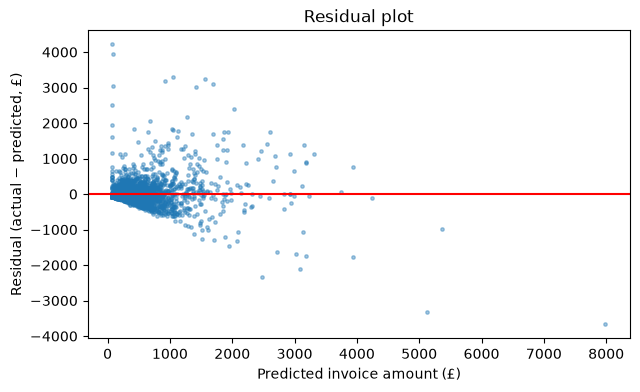

In [15]:
resid = y_test - pred
plt.figure(figsize=(7, 4))
plt.scatter(pred, resid, s=6, alpha=0.4)
plt.axhline(0, color="red")
plt.xlabel("Predicted invoice amount (£)"); plt.ylabel("Residual (actual − predicted, £)")
plt.title("Residual plot")
plt.show()

**What we see:** the points are **not** a neat random cloud – they form a **funnel**. For small predicted bills the errors are small, but as the predicted amount grows the errors spread out much wider (some invoices are off by £1,000–£4,000). A few points far above the red line are bills the model badly **under-predicted**, and these are what push RMSE to about double the MAE.

**What it tells us:** an R² of 0.63 hides the fact that the model is reliable for small bills and unreliable for big ones. Ideas to improve it: add more features (e.g. average unit price, country) or predict the *logarithm* of the amount.